# «Предсказание рейтинга настольных игр»

In [175]:
# Импортируем необходимые библиотеки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [176]:
# считываем датасеты

train = pd.read_csv('data/train_data.csv')
test = pd.read_csv('data/test_data.csv')
sample_submit = pd.read_csv('data/sample_submition.csv')

In [ ]:
print("Размер train:", train.shape)
print("Размер test:", test.shape)
print("Размер sample_submit:", sample_submit.shape)

Размер train: (15257, 14)
Размер test: (5086, 13)
Размер sample_submit: (5086, 2)


In [ ]:
# первичный анализ

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  object 
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  object 
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 1.6+ MB


In [179]:
train.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"


__Вывод пераичного анализа__
- Имеется пропуски в колонках: ID, Year Published, Owned Users, Mechanics, Domains.
- Целевая переменная __Rating Average__ имеет тип object.
- Колонка __Complexity Average__ также представлена как object.

In [180]:
# Преобразуем целевую переменую Rating Average в числовой (float)

train['Rating Average'] = (
    train['Rating Average']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

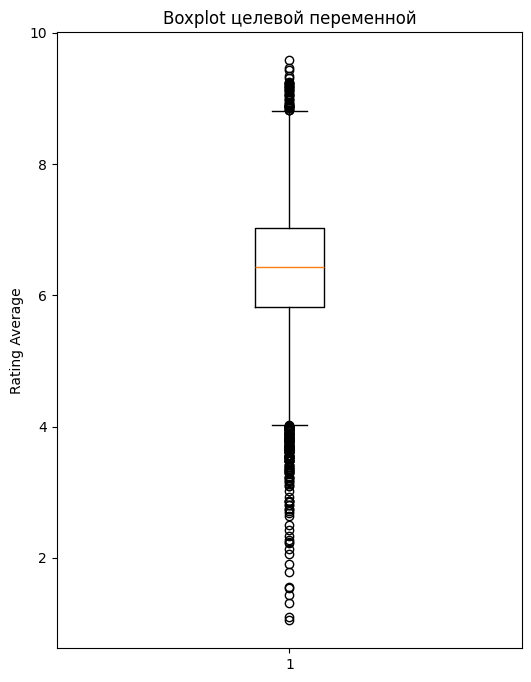

In [181]:
# анализ распределения целевой переменной

plt.figure(figsize=(6, 8))
plt.boxplot(train['Rating Average'])
plt.ylabel("Rating Average")
plt.title("Boxplot целевой переменной")
plt.show()

In [182]:
train['Rating Average'].describe()

count    15257.000000
mean         6.399775
std          0.936488
min          1.050000
25%          5.820000
50%          6.430000
75%          7.020000
max          9.580000
Name: Rating Average, dtype: float64

__Вывод после преобразования целевой переменной:__
- Значения Rating Average распределены в разумном диапазоне.
- Boxplot позволяет визуально оценить наличие выбросов.

In [183]:
# Преобразуем Complexity Average в числовой (float) в train и в test

train['Complexity Average'] = (
    train['Complexity Average']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

test['Complexity Average'] = (
    test['Complexity Average']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [184]:
# обработка данных в колонке Year Published в train и в test

train.loc[train['Year Published'] == 0, 'Year Published'] = np.nan
test.loc[test['Year Published'] == 0, 'Year Published'] = np.nan

In [185]:
# для коректной инторпритации возраста игры создаём новый признак Game Age в train и в test
# возраст игры в кол-ве лет(год) от текущего года.

train['Game Age'] = 2026 - train['Year Published']
test['Game Age'] = 2026 - test['Year Published']

In [186]:
# Пропуски в Game Age заполним медианой по train

median_age = train['Game Age'].median()

train['Game Age'] = train['Game Age'].fillna(median_age)
test['Game Age'] = test['Game Age'].fillna(median_age)

In [187]:
# и в train и в test удаляем колонка Domains - содержит очень много пропусков.

train.drop(columns=['Domains'], inplace=True)
test.drop(columns=['Domains'], inplace=True)

In [188]:
# что б избежать исключения baseline-модель обрабатываем train - даляем строки, где есть пропуски

train = train.dropna().reset_index(drop=True)

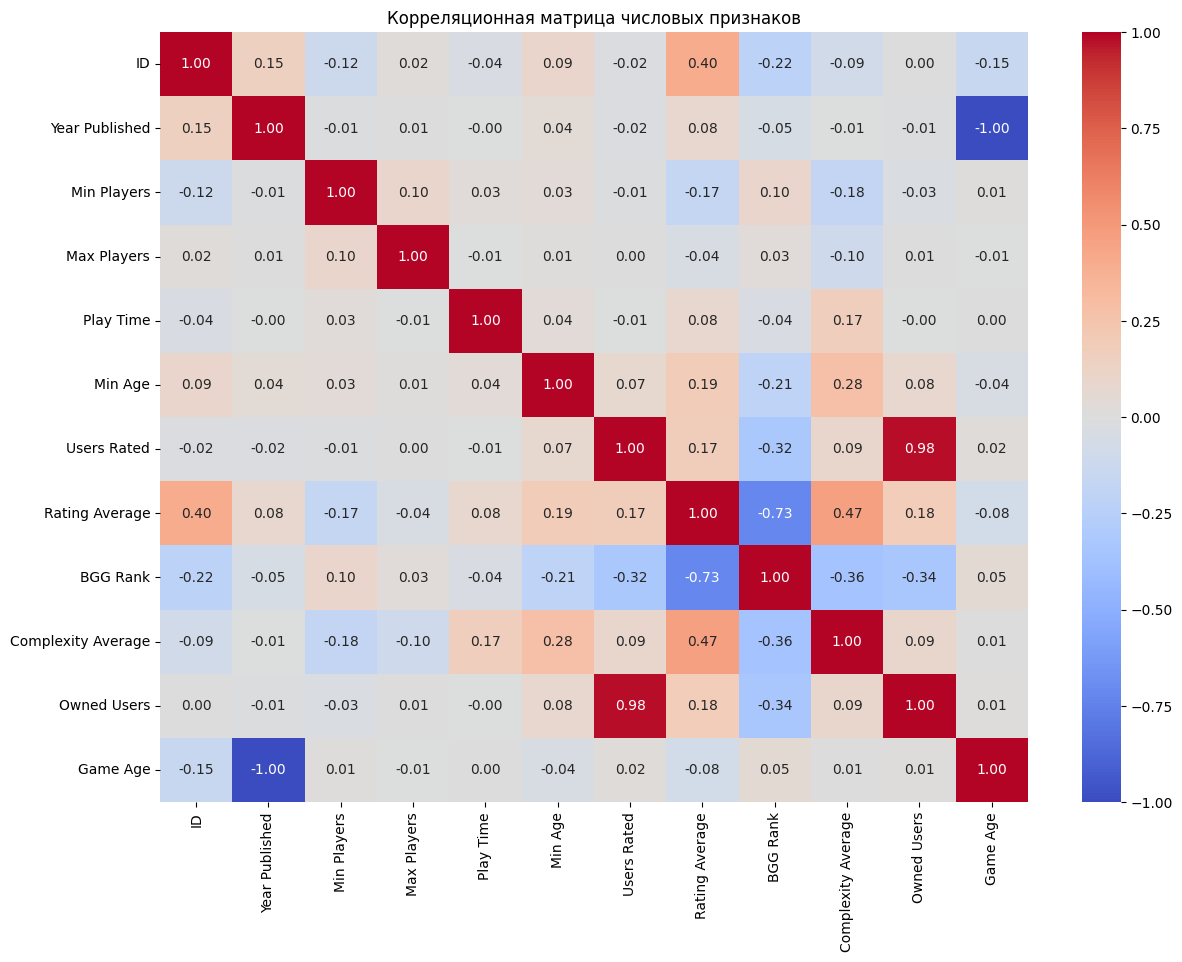

In [189]:
# корреляционный анализ

numeric_train = train.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_train.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица числовых признаков")
plt.show()

__Вывод после корреляционного анализа__
1. Сильные положительные корреляции:
- Users Rated и Owned Users
- Rating Average и Complexity Average
2. Сильные отрицательные корреляции:
- Rating Average и BGG Rank
- Year Published и Game Age
3. Слабые корреляции:
- Min Players
- Max Players
- Play Time

In [190]:
# формируем признаки и целевую переменную

X = train.drop(columns=['ID', 'Name', 'Year Published', 'Mechanics', 'Rating Average'])
y = train['Rating Average']

In [191]:
print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Признаки:", X.columns.tolist())

Размер X: (13930, 9)
Размер y: (13930,)
Признаки: ['Min Players', 'Max Players', 'Play Time', 'Min Age', 'Users Rated', 'BGG Rank', 'Complexity Average', 'Owned Users', 'Game Age']


In [192]:
# Разделяем на обучающую и валидационную выборки

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Valid dataset size: {X_valid.shape}, {y_valid.shape}')

Train dataset size: (9751, 9), (9751,)
Valid dataset size: (4179, 9), (4179,)


In [193]:
# обучим Linear Regression
# Она даёт первую оценку качества, с которой можно сравнивать более сложные алгоритмы.

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_valid)

print('=== Linear Regression ===')
print('Mean Absolute Error:', mean_absolute_error(y_valid, y_pred_lin))
print('Mean Squared Error:', mean_squared_error(y_valid, y_pred_lin))
print('R2 score:', r2_score(y_valid, y_pred_lin))

=== Linear Regression ===
Mean Absolute Error: 0.43858358415220544
Mean Squared Error: 0.3551186765493538
R2 score: 0.5854220986742125


In [194]:
# кросс-валидация для Linear Regression

lin_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("Linear Regression neg_MSE на каждом фолде::", lin_scores)
print("Среднее Linear Regression MSE:", -np.mean(lin_scores))

Linear Regression neg_MSE на каждом фолде:: [-0.81054631 -0.33186354 -0.53538828 -0.43390767 -1.05437835]
Среднее Linear Regression MSE: 0.6332168287210467


In [195]:
# Обучаем Random Forest Regressor
# Для табличных данных и нелинейных зависимостей часто лучше работает Random Forest Regressor.

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

print('=== Random Forest Regressor ===')
print('Mean Absolute Error:', mean_absolute_error(y_valid, y_pred_rf))
print('Mean Squared Error:', mean_squared_error(y_valid, y_pred_rf))
print('R2 score:', r2_score(y_valid, y_pred_rf))

=== Random Forest Regressor ===
Mean Absolute Error: 0.14410693148281112
Mean Squared Error: 0.058968467504187626
R2 score: 0.9311581589010388


In [196]:
# Кросс-валидация для Random Forest Regressor

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("Random Forest Regressor neg_MSE на каждом фолде:", rf_scores)
print("Среднее Random Forest Regressor MSE:", -np.mean(rf_scores))

Random Forest Regressor neg_MSE на каждом фолде: [-0.74280459 -0.14308255 -0.12856252 -0.35104904 -0.80369855]
Среднее Random Forest Regressor MSE: 0.43383945160588355


>__Linear Regression VS Random Forest Regressor__
>> MSE После обучения моделей:
>>> Linear Regression - 0.3551186765493538 \
>>> Random Forest Regressor - 0.058968467504187626

>> Среднее MSE после кросс-валидация:
>>> Linear Regression - 0.6332168287210467 \
>>> Random Forest Regressor - 0.4338394516058835

__ВЫВОД: т.к. MSE и средняя MSE у Random Forest Regressor меньше чем Linear Regression, следовательно у Random Forest Regressor качество на данной задаче лучше.__

In [197]:
# чтобы улучшить качество модели, выполним подбор гиперпараметров с помощью RandomizedSearchCV

# задаём сетку параметров
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

#запуск RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [198]:
print("Лучшие параметры:", rf_search.best_params_)
print("Лучший MSE:", -rf_search.best_score_)

Лучшие параметры: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Лучший MSE: 0.3802282943028599


In [199]:
# лучшую модель после подбора гиперпараметров
best_model = rf_search.best_estimator_
best_model

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [200]:
# проведём анализ важности признаков (Feature Importance)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
5,BGG Rank,0.540445
6,Complexity Average,0.128450
8,Game Age,0.120489
4,Users Rated,0.064323
7,Owned Users,0.054193
2,Play Time,0.047011
3,Min Age,0.020105
1,Max Players,0.016076
0,Min Players,0.008908


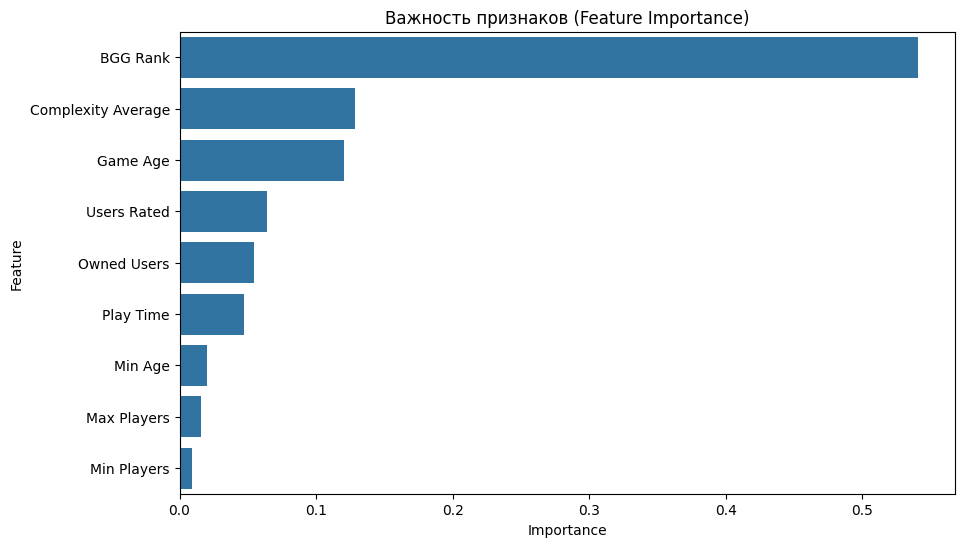

In [201]:
# построим график важности признаков

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Важность признаков (Feature Importance)')
plt.show()

In [202]:
# После выбора лучших параметров обучаем финальную модель на всём тренировочном наборе.

best_model.fit(X, y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [203]:
# подготавливаем test

# формируем X_test
X_test = test.drop(columns=['ID', 'Name', 'Year Published', 'Mechanics'])

# заполняем пропуски медианой из train
median_owned_users = train['Owned Users'].median()
X_test['Owned Users'] = X_test['Owned Users'].fillna(median_owned_users)

# проверим пропуски в test
X_test.isnull().sum()

Min Players           0
Max Players           0
Play Time             0
Min Age               0
Users Rated           0
BGG Rank              0
Complexity Average    0
Owned Users           0
Game Age              0
dtype: int64

In [204]:
# предсказания для test

test_predictions = best_model.predict(X_test)
test_predictions[:10]

array([7.89353381, 7.92458994, 7.98819502, 8.23979043, 7.96349429,
       8.18167002, 7.98715643, 8.07639776, 8.03830325, 8.16633438])

In [205]:
# Итог:

submission = pd.DataFrame({
    'index': np.arange(len(test_predictions)),
    'Rating Average': test_predictions
})

# сохраням .csv
submission.to_csv('my_submit_final.csv', index=False)

In [206]:
#проверяем результат

check_submission = pd.read_csv('my_submit_final.csv')
check_submission.head()

,index,Rating Average
0,0,7.893534
1,1,7.924590
2,2,7.988195
3,3,8.239790
4,4,7.963494


![Участие в Kaggle.JPG](<attachment:Участие в Kaggle.JPG>)
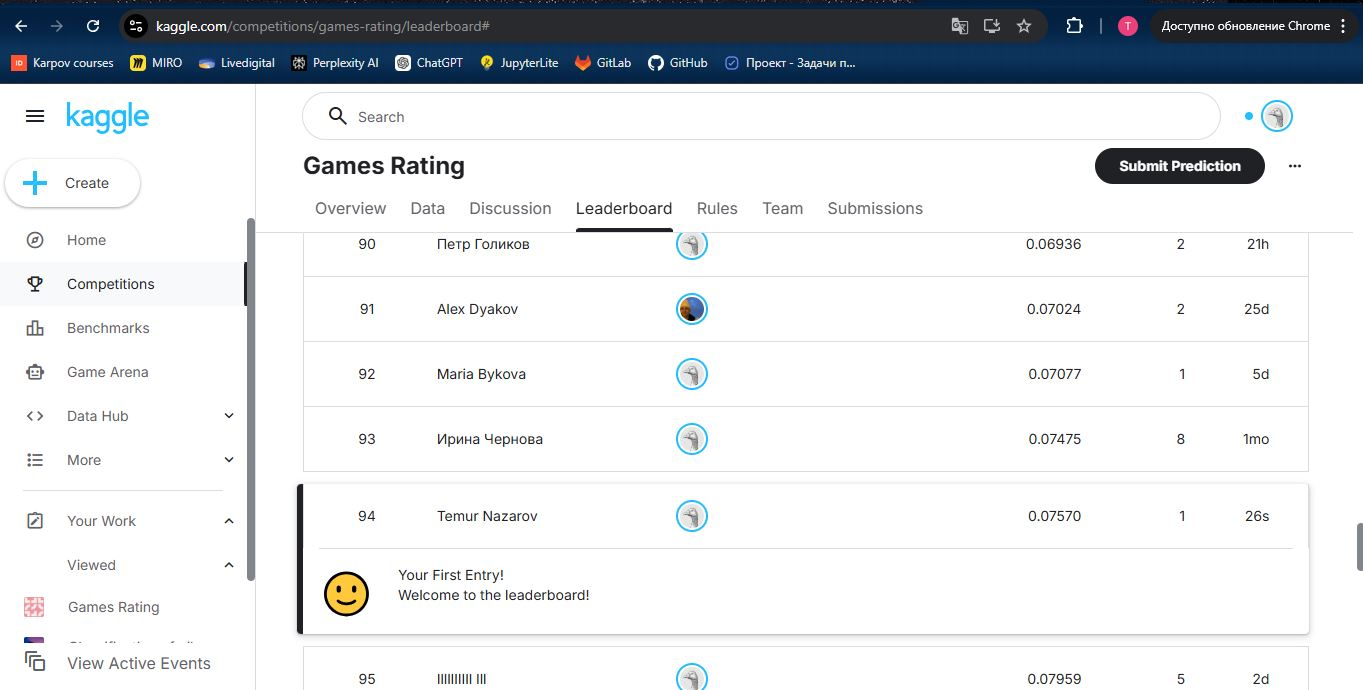